In [1]:
import pandas as pd
df = pd.read_pickle('cleaned_three.pkl')
df.head()


,age,insurance_type,discharge_disposition,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group,risk_score_bin,dc_location,primary_dx_tier
0,66,Medicare,Home Health,1,1,five or more,6 to 8,8 to 14,5 or more,7,Home Health,lower
1,55,Private,Home Health,1,2,four,6 to 8,6,4,7,Home Health,lower
2,69,Medicare,Skilled Nursing,1,2,five or more,6 to 8,8 to 14,5 or more,7,Skilled Nursing,lower
3,83,Medicare,Skilled Nursing,1,2,five or more,9+,8 to 14,4,7,Skilled Nursing,higher
4,54,Uninsured,Home Health,1,1,four,9+,6,2,6,Home Health,higher


In [2]:
df.groupby('age')['label'].agg(['count', 'mean'])

,count,mean
age,,
18,89,0.292135
19,9,0.222222
20,23,0.260870
21,22,0.318182
22,28,0.428571
...,...,...
91,25,0.920000
92,24,0.958333
93,29,1.000000


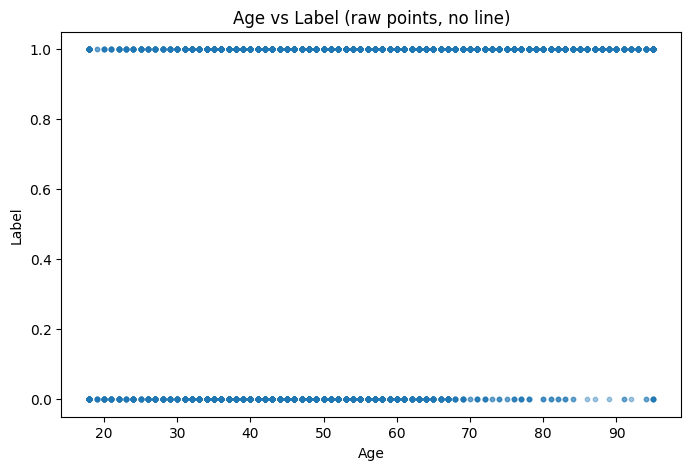

In [3]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('age')

plt.figure(figsize=(8,5))
plt.scatter(df_sorted['age'], df_sorted['label'], s=10, alpha=0.4)
plt.xlabel('Age')
plt.ylabel('Label')
plt.title('Age vs Label (raw points, no line)')
plt.show()


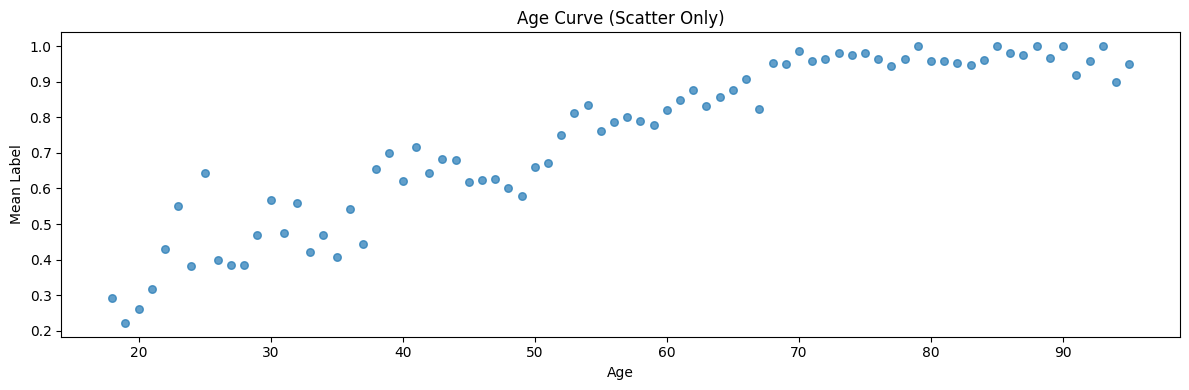

In [4]:
import matplotlib.pyplot as plt

# Compute the mean label at each age
age_curve = df.groupby('age')['label'].mean()

plt.figure(figsize=(12,4))

# Scatter plot instead of a line
plt.scatter(age_curve.index, age_curve.values, s=30, alpha=0.7)

plt.xlabel("Age")
plt.ylabel("Mean Label")
plt.title("Age Curve (Scatter Only)")

plt.tight_layout()
plt.show()


In [5]:
data = df.groupby('age')['label'].agg(['count', 'mean'])
print(data.to_string())

     count      mean
age                 
18      89  0.292135
19       9  0.222222
20      23  0.260870
21      22  0.318182
22      28  0.428571
23      20  0.550000
24      34  0.382353
25      28  0.642857
26      35  0.400000
27      39  0.384615
28      39  0.384615
29      34  0.470588
30      44  0.568182
31      63  0.476190
32      68  0.558824
33      57  0.421053
34      83  0.469880
35      81  0.407407
36      83  0.542169
37      90  0.444444
38      90  0.655556
39     100  0.700000
40     108  0.620370
41     120  0.716667
42     132  0.643939
43     142  0.683099
44     144  0.680556
45     141  0.617021
46     136  0.625000
47     179  0.625698
48     160  0.600000
49     169  0.579882
50     162  0.660494
51     173  0.670520
52     173  0.751445
53     170  0.811765
54     201  0.835821
55     164  0.762195
56     182  0.785714
57     201  0.800995
58     201  0.791045
59     184  0.777174
60     161  0.819876
61     204  0.848039
62     164  0.878049
63     191  0

In [6]:
# oldest/highest risk:
# 68 and older highest
# then ages 52 to 67
# then 38 to 51
# then 30 to 37
#  then 21 and under
means = df.groupby('age')['label'].mean()
def age_map(age):
    if age <= 21:
        return 1
    elif age <= 37:
        return 2
    elif age <= 51:
        return 3
    elif age <= 67:
        return 4
    else:
        return 5

df['age_bin'] = df['age'].apply(age_map)

In [7]:
df['age_bin'].value_counts()

age_bin
4    2864
5    2211
3    1956
2     826
1     143
Name: count, dtype: int64

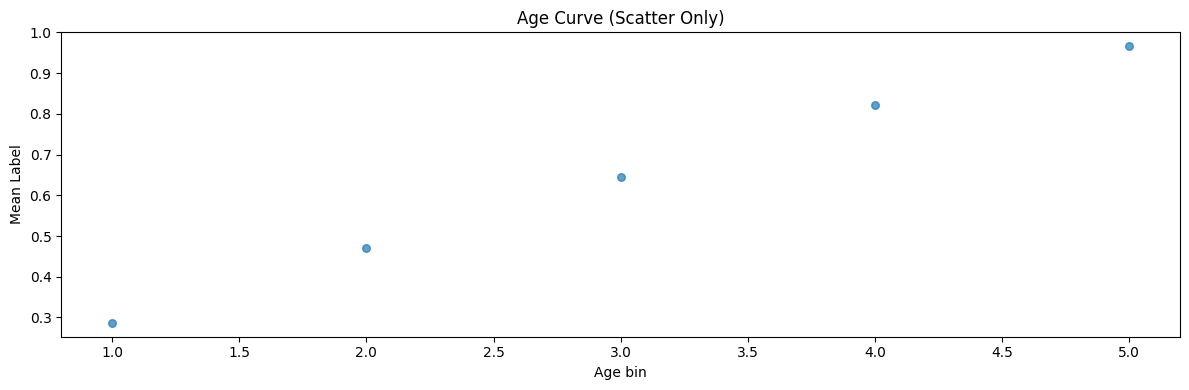

In [8]:
import matplotlib.pyplot as plt

# Compute the mean label at each age
age_curve = df.groupby('age_bin')['label'].mean()

plt.figure(figsize=(12,4))

# Scatter plot instead of a line
plt.scatter(age_curve.index, age_curve.values, s=30, alpha=0.7)

plt.xlabel("Age bin")
plt.ylabel("Mean Label")
plt.title("Age Curve (Scatter Only)")

plt.tight_layout()
plt.show()

In [9]:
df2 = df.copy()
df2 = df2.drop(columns=['age', 'discharge_disposition'])
df2.head()

,insurance_type,label,prev_readmit_group,comorbidities_group,los_group,medications_group,followup_visits_group,risk_score_bin,dc_location,primary_dx_tier,age_bin
0,Medicare,1,1,five or more,6 to 8,8 to 14,5 or more,7,Home Health,lower,4
1,Private,1,2,four,6 to 8,6,4,7,Home Health,lower,4
2,Medicare,1,2,five or more,6 to 8,8 to 14,5 or more,7,Skilled Nursing,lower,5
3,Medicare,1,2,five or more,9+,8 to 14,4,7,Skilled Nursing,higher,5
4,Uninsured,1,1,four,9+,6,2,6,Home Health,higher,4


In [10]:
df2.to_pickle('final_cleaned.pkl')